In [1]:
pip install tensorflow numpy pandas matplotlib scikit-learn pillow

Note: you may need to restart the kernel to use updated packages.


In [9]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

In [4]:
import opendatasets as od
# Wuxuu toos u soo dejinayaa dataset-ka marka koodhka la ordayo
od.download("https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset")

ModuleNotFoundError: No module named 'opendatasets'

In [5]:
!pip install opendatasets



   ---------------------------------------- 0/3 [jupytext]
   ---------------------------------------- 0/3 [jupytext]
   ---------------------------------------- 0/3 [jupytext]
   ---------------------------------------- 0/3 [jupytext]
   ---------------------------------------- 0/3 [jupytext]
   ------------- -------------------------- 1/3 [kaggle]
   ------------- -------------------------- 1/3 [kaggle]
   -------------------------- ------------- 2/3 [opendatasets]
   -------------------------- ------------- 2/3 [opendatasets]
   ---------------------------------------- 3/3 [opendatasets]



In [6]:
!pip install kagglehub

In [7]:
import kagglehub

# Soo deji dataset-ka Brain Tumor MRI
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Xogta waxay ku soo degtay khaanadda:", path)

Xogta waxay ku soo degtay khaanadda: C:\Users\muhid\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2


In [10]:
# 2. TOOS U SOO DEJI DATASET-KA (KAGGLEHUB)
# ---------------------------------------------------------
print("Downloading Brain Tumor MRI Dataset...")
dataset_path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Dataset location:", dataset_path)

# Qeex khaanadaha Training iyo Testing
TRAIN_DIR = os.path.join(dataset_path, "Training")
TEST_DIR = os.path.join(dataset_path, "Testing")

Dataset location: C:\Users\muhid\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2


In [11]:
# 3. PARAMETERS & DATA AUGMENTATION
# ---------------------------------------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 4

# Preprocessing iyo Data Augmentation si looga hortago Overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [12]:
# 4. BUILD MODEL (MOBILENETV2 TRANSFER LEARNING)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
# 5. TABABARKA MOODEELKA (MODEL TRAINING)
# ---------------------------------------------------------
print("\n--- Model Training Started ---")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator
)


--- Model Training Started ---
Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.7625 - loss: 0.6250 - val_accuracy: 0.7900 - val_loss: 0.5988
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.8327 - loss: 0.4400 - val_accuracy: 0.8031 - val_loss: 0.5862
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.8525 - loss: 0.3933 - val_accuracy: 0.8156 - val_loss: 0.5436
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.8705 - loss: 0.3573 - val_accuracy: 0.8087 - val_loss: 0.6060
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.8752 - loss: 0.3279 - val_accuracy: 0.8119 - val_loss: 0.6027
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.8827 - loss: 0.3136 - val_accuracy: 0.7962 - val_loss: 0.6734
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.8832 - loss: 0.3164 - val_accuracy: 0.7544 - val_loss: 0.7609
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 

In [14]:
# 6. KAYDI MOODEELKA (SAVE MODEL)
# ---------------------------------------------------------
model.save("brain_tumor_model.h5")
print("\nMoodeelka waxaa loo kaydiyay sida 'brain_tumor_model.h5'")


Moodeelka waxaa loo kaydiyay sida 'brain_tumor_model.h5'


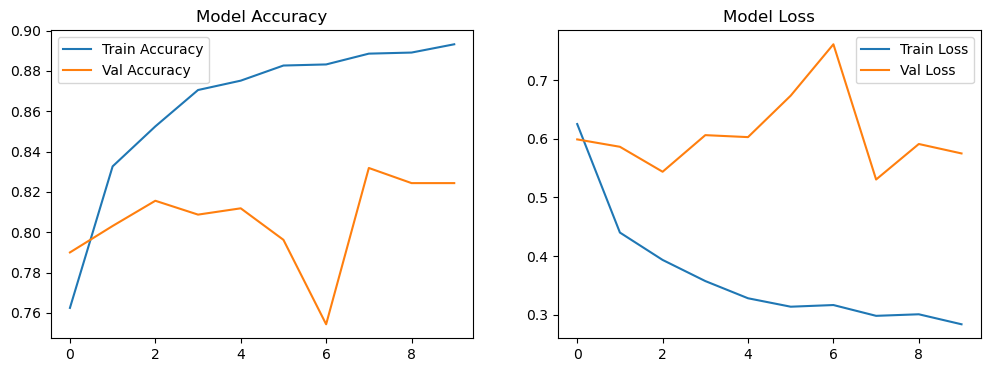

In [15]:
# 7. GRAPHS-KA ACCURACY IYO LOSS
# ---------------------------------------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss')

plt.savefig('training_results.png')
plt.show()